# ITEC5920 - Assignment 3 - Question 1
Earle Estrella

100907269

## Question 1.1

In [36]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Flatten, SimpleRNN, LSTM, GRU
from keras.backend import clear_session
from keras.callbacks import EarlyStopping

np.random.seed(42)

def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.6 * np.sin((time - offsets1) * (freq1 * 10 + 10))
    return series[..., np.newaxis].astype(np.float32)

n_steps = 60
series  = generate_time_series(11000, n_steps + 1)

X_train, y_train = series[:8000,      :n_steps], series[:8000,      -1]
X_valid, y_valid = series[8000:10000, :n_steps], series[8000:10000, -1]
X_test,  y_test  = series[10000:,     :n_steps], series[10000:,     -1]

print("X_train:", X_train.shape, "  y_train:", y_train.shape)
print("X_valid:", X_valid.shape, "  y_valid:", y_valid.shape)
print("X_test: ", X_test.shape,  "  y_test: ", y_test.shape)

X_train: (8000, 60, 1)   y_train: (8000, 1)
X_valid: (2000, 60, 1)   y_valid: (2000, 1)
X_test:  (1000, 60, 1)   y_test:  (1000, 1)


In [37]:
# Model Creation Functions
# Create linear prediction model
def create_linear(dense_units, input_shape):
    clear_session()
    model = Sequential([
        Flatten(input_shape=input_shape),
        Dense(dense_units)
    ], name="Linear")
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

# Create simple RNN model
def create_simple_RNN(hidden_units, dense_units, input_shape, activation):
    clear_session()
    model = Sequential([
        SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]),
        Dense(units=dense_units, activation=activation[1])
    ], name="SimpleRNN")
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

# Create deep RNN model
def create_deep_RNN(hidden_units, dense_units, input_shape, activation):
    clear_session()
    model = Sequential([
        SimpleRNN(hidden_units, return_sequences=True, input_shape=input_shape, activation=activation[0]),
        SimpleRNN(hidden_units, activation=activation[0]),
        Dense(units=dense_units, activation=activation[1])
    ], name="DeepRNN")
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

# Create LSTM model
def create_LSTM(hidden_units, dense_units, input_shape, activation):
    clear_session()
    model = Sequential([
        LSTM(hidden_units, input_shape=input_shape, activation=activation[0]),
        Dense(units=dense_units, activation=activation[1])
    ], name="LSTM")
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

# Create GRU model
def create_GRU(hidden_units, dense_units, input_shape, activation):
    clear_session()
    model = Sequential([
        GRU(hidden_units, input_shape=input_shape, activation=activation[0]),
        Dense(units=dense_units, activation=activation[1])
    ], name="GRU")
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

In [38]:
# Helper code to calculate error
def print_error(model, X_train, Y_train, X_valid, Y_valid, X_test, Y_test):
    train_mse = model.evaluate(X_train, Y_train, verbose=0)
    valid_mse = model.evaluate(X_valid, Y_valid, verbose=0)
    test_mse  = model.evaluate(X_test,  Y_test,  verbose=0)
    print('Train MSE: %.6f' % train_mse)
    print('Valid MSE: %.6f' % valid_mse)
    print('Test  MSE: %.6f' % test_mse)
    return train_mse, valid_mse, test_mse

results = {}

In [ ]:
input_shape  = (n_steps, 1)
hidden_units = 20
dense_units  = 1

# Create histories to keep track for plot purposes
histories_1 = {}
# Create models and put them in an array
models_to_train = [
    ("Linear",    create_linear(dense_units, input_shape)),
    ("SimpleRNN", create_simple_RNN(hidden_units, dense_units, input_shape, activation=['tanh', 'tanh'])),
    ("DeepRNN",   create_deep_RNN(hidden_units, dense_units, input_shape, activation=['tanh', 'tanh'])),
    ("LSTM",      create_LSTM(hidden_units, dense_units, input_shape, activation=['tanh', 'tanh'])),
    ("GRU",       create_GRU(hidden_units, dense_units, input_shape, activation=['tanh', 'tanh'])),
]

# Loop over the models
for name, model in models_to_train:
    print(f"\n{'='*40}\nTraining: {name}\n{'='*40}")
    model.summary()
    histories_1[name] = model.fit(
        X_train, y_train,
        epochs          = 20,
        batch_size      = 64,
        validation_data = (X_valid, y_valid),
        verbose         = 1
    )
    print(f"\n{name} — MSE:")
    results[name] = print_error(
        model, X_train, y_train, X_valid, y_valid, X_test, y_test)

c:\Users\Earle\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Earle\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training: Linear


Model: "Linear"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (244.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 20)             │         1,380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,401 (5.47 KB)

 Trainable params: 1,401 (5.47 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0842 - val_loss: 0.0068
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0037 - val_loss: 0.0021
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0016 - val_loss: 0.0011
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.7099e-04 - val_loss: 7.6249e-04
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.0230e-04 - val_loss: 6.0887e-04
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.9656e-04 - val_loss: 5.4167e-04
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.3771e-04 - val_loss: 4.7908e-04
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.7324e-04 - val_loss: 4.2518e-04
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.2811e-04 - val_loss: 4.0153e-04
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.8210e-04 - val_loss: 3.3963e-04
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.4198e-04 - val_loss:

In [40]:
print(f"\n{'Model':<12}  {'Train MSE':>12}  {'Valid MSE':>12}  {'Test MSE':>12}")
print("-" * 52)
for name, (tr, va, te) in results.items():
    print(f"{name:<12}  {tr:>12.6f}  {va:>12.6f}  {te:>12.6f}")


Model            Train MSE     Valid MSE      Test MSE
----------------------------------------------------
Linear            0.000320      0.000331      0.000331
SimpleRNN         0.000046      0.000048      0.000046
DeepRNN           0.000006      0.000006      0.000006
LSTM              0.000033      0.000033      0.000034
GRU               0.000135      0.000132      0.000120


## Question 1.2

In [41]:
series = generate_time_series(11000, n_steps + 10)

X_train, Y_train = series[:8000,      :n_steps], series[:8000,      -10:, 0]
X_valid, Y_valid = series[8000:10000, :n_steps], series[8000:10000, -10:, 0]
X_test,  Y_test  = series[10000:,     :n_steps], series[10000:,     -10:, 0]

print("X_train:", X_train.shape, "  Y_train:", Y_train.shape)
print("X_valid:", X_valid.shape, "  Y_valid:", Y_valid.shape)
print("X_test: ", X_test.shape,  "  Y_test: ", Y_test.shape)

X_train: (8000, 60, 1)   Y_train: (8000, 10)
X_valid: (2000, 60, 1)   Y_valid: (2000, 10)
X_test:  (1000, 60, 1)   Y_test:  (1000, 10)


In [ ]:
input_shape  = (n_steps, 1)
hidden_units = 20
dense_units  = 10

# Create histories to keep track for plot purposes
histories_2 = {}
# Create models and put them in an array
models_to_train = [
    ("Linear",    create_linear(dense_units, input_shape)),
    ("SimpleRNN", create_simple_RNN(hidden_units, dense_units, input_shape, activation=['tanh', 'tanh'])),
    ("DeepRNN",   create_deep_RNN(hidden_units, dense_units, input_shape, activation=['tanh', 'tanh'])),
    ("LSTM",      create_LSTM(hidden_units, dense_units, input_shape, activation=['tanh', 'tanh'])),
    ("GRU",       create_GRU(hidden_units, dense_units, input_shape, activation=['tanh', 'tanh'])),
]

# Loop over the models
for name, model in models_to_train:
    print(f"\n{'='*40}\nTraining: {name}\n{'='*40}")
    model.summary()
    histories_2[name] = model.fit(
        X_train, Y_train,
        epochs          = 20,
        batch_size      = 64,
        validation_data = (X_valid, Y_valid),
        verbose         = 1
    )
    print(f"\n{name} — MSE:")
    results[name] = print_error(
        model, X_train, Y_train, X_valid, Y_valid, X_test, Y_test)


Training: Linear


Model: "Linear"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 610 (2.38 KB)

 Trainable params: 610 (2.38 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 20)             │         1,380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,590 (6.21 KB)

 Trainable params: 1,590 (6.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1285 - val_loss: 0.0411
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0228 - val_loss: 0.0180
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0161 - val_loss: 0.0149
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0134 - val_loss: 0.0124
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0111 - val_loss: 0.0101
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0092 - val_loss: 0.0086
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0077 - val_loss: 0.0067
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0055 - val_loss: 0.0049
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0031 - val_loss: 0.0023
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 12/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

In [43]:
print(f"\n{'Model':<12}  {'Train MSE':>12}  {'Valid MSE':>12}  {'Test MSE':>12}")
print("-" * 52)
for name, (tr, va, te) in results.items():
    print(f"{name:<12}  {tr:>12.6f}  {va:>12.6f}  {te:>12.6f}")


Model            Train MSE     Valid MSE      Test MSE
----------------------------------------------------
Linear            0.003507      0.003721      0.003448
SimpleRNN         0.000549      0.000553      0.000532
DeepRNN           0.000243      0.000256      0.000252
LSTM              0.000212      0.000215      0.000217
GRU               0.000324      0.000333      0.000318


## Question 1.3

In [46]:
def plot_loss(histories, title):
    fig, axes = plt.subplots(1, len(histories), figsize=(20, 4))
    for ax, (name, history) in zip(axes, histories.items()):
        ax.plot(history.history['loss'],     label='Train loss')
        ax.plot(history.history['val_loss'], label='Valid loss')
        ax.set_title(name)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_loss_combined(histories, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for name, history in histories.items():
        axes[0].plot(history.history['loss'],     label=name)
        axes[1].plot(history.history['val_loss'], label=name)

    axes[0].set_title('Train Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].set_title('Validation Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

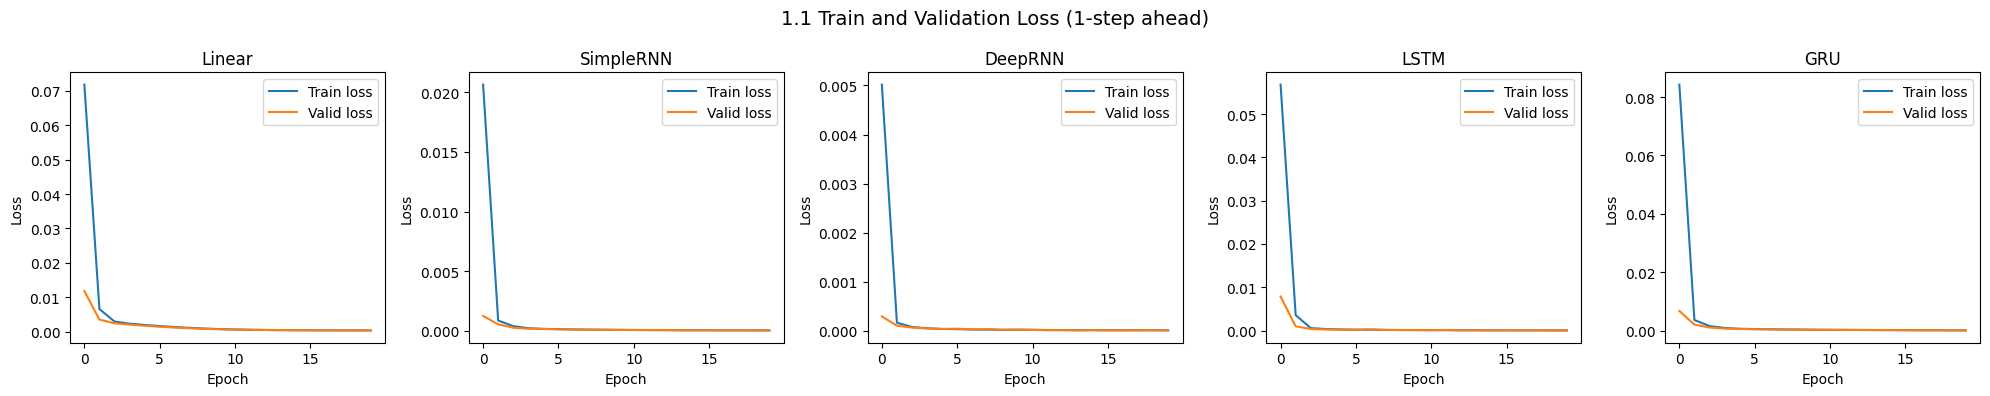

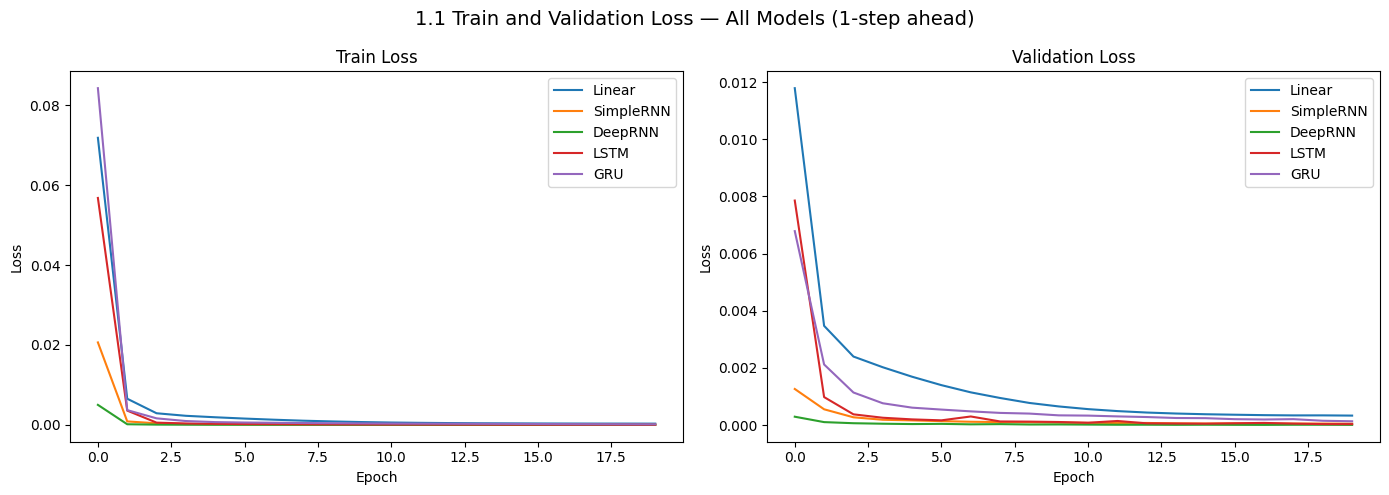

In [48]:
plot_loss(histories_1, title='1.1 Train and Validation Loss (1-step ahead)')
plot_loss_combined(histories_1, title='1.1 Train and Validation Loss — All Models (1-step ahead)')

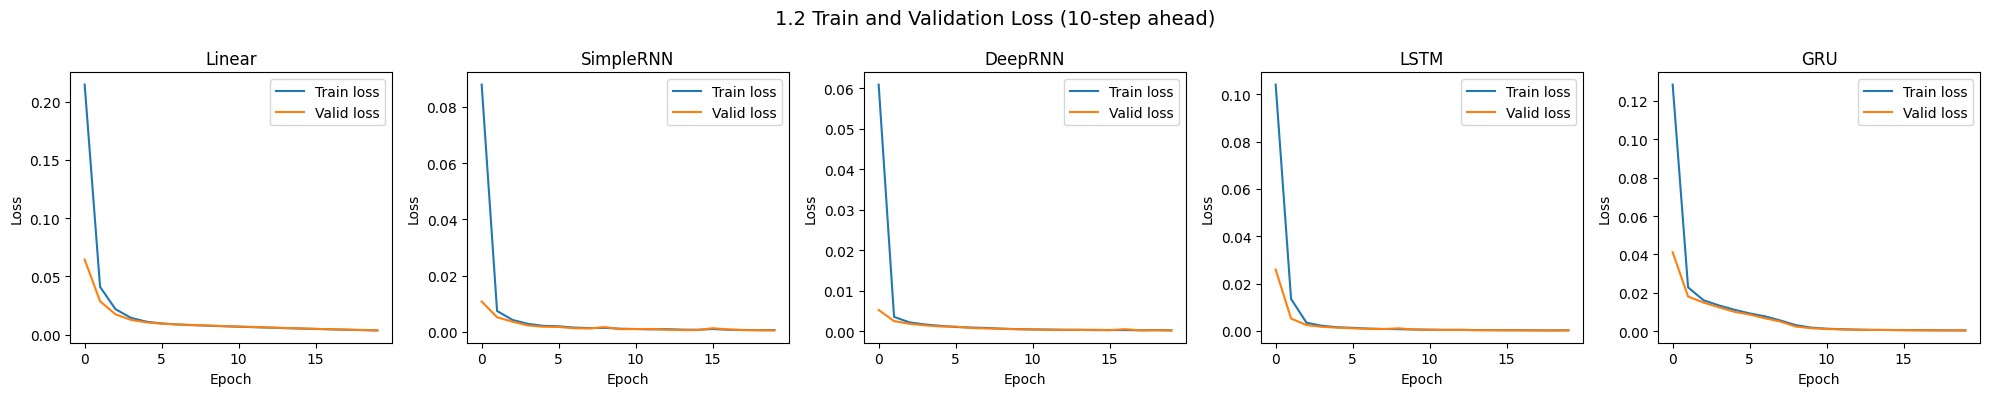

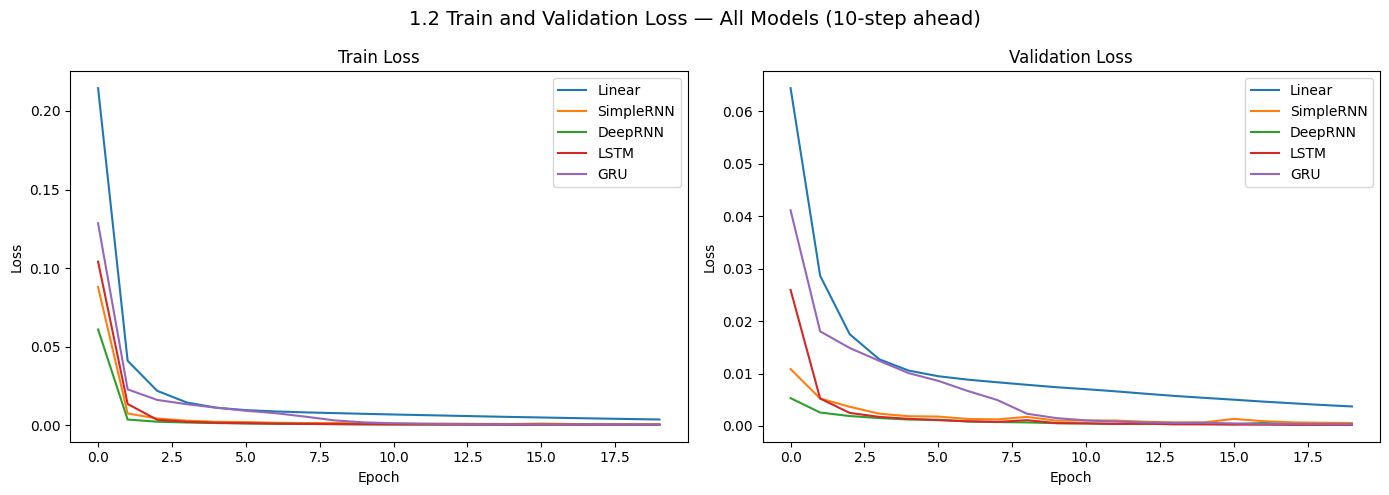

In [49]:
plot_loss(histories_2, title='1.2 Train and Validation Loss (10-step ahead)')
plot_loss_combined(histories_2, title='1.2 Train and Validation Loss — All Models (10-step ahead)')